# 构造full-text，调用LLM处理
经筛选后剩72列

## 步骤一.导入所需库

In [1]:
import pandas as pd
import numpy as np
import os
import torch
from transformers import BertTokenizerFast, BertModel
from tqdm import tqdm
import pickle
import warnings

# 忽略 pandas 中关于 .iloc[] 赋值的常见警告
pd.options.mode.chained_assignment = None  # default='warn'
warnings.filterwarnings('ignore', category=UserWarning, module='transformers')

## 步骤 2：定义常量和路径

In [11]:
# --- 路径定义 ---
RAW_DATA_FILE = os.path.join('..', 'data', 'raw', 'california_raw_data.csv')
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
OUTPUT_FILE = os.path.join(PROCESSED_DIR, 'california_nlp_features.pkl')
COLUMNS_CONFIG_FILE = os.path.join('..', 'config', 'columns_to_keep.txt')

# --- 模型定义 ---
# 您可以选择 "bert-base-uncased" (768维) 或 "bert-large-uncased" (1024维)
# "bert-base-uncased" 对大多数任务来说速度和性能都很好
MODEL_NAME = 'bert-base-uncased'

# --- 硬件设置 ---
# 检查是否有可用的 GPU，否则使用 CPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"将使用以下设备进行处理: {DEVICE.upper()}")

# --- 从文件加载要保留的列 ---
try:
    with open(COLUMNS_CONFIG_FILE, 'r') as f:
        # 读取每一行 (line.strip() 会去除末尾的换行符)
        # if line.strip() 会跳过空行
        COLUMNS_TO_KEEP = [line.strip() for line in f if line.strip()]
    
    print(f"成功从 {COLUMNS_CONFIG_FILE} 加载 {len(COLUMNS_TO_KEEP)} 个要保留的列名。")
    
    # --- 关键验证 ---
    if not COLUMNS_TO_KEEP:
        print("--- 警告: 'columns_to_keep.txt' 文件为空! ---")
    elif 'narrative' not in COLUMNS_TO_KEEP[0].lower(): # 检查第一个是否是 'Narrative'
        print(f"--- 警告: 'columns_to_keep.txt' 中的第一行 ('{COLUMNS_TO_KEEP[0]}') 不是 'Narrative'。")
        print(f"--- 请确保 'Narrative' 是文件中的第一个列名，以避免被截断。 ---")

except FileNotFoundError:
    print(f"--- 错误: 未找到列配置文件: {COLUMNS_CONFIG_FILE} ---")
    print(f"--- 请在 'config' 文件夹中创建 'columns_to_keep.txt' 文件。 ---")
    COLUMNS_TO_KEEP = [] # 设置为空列表以避免后续代码出错

将使用以下设备进行处理: CPU
成功从 ..\config\columns_to_keep.txt 加载 72 个要保留的列名。


## 步骤 3：加载原始数据

In [12]:
try:
    df_raw = pd.read_csv(RAW_DATA_FILE, low_memory=False)
    print(f"成功加载原始数据: {RAW_DATA_FILE}")
    print(f"原始数据形状: {df_raw.shape}")
    print(df_raw.head())
except FileNotFoundError:
    print(f"错误: 原始数据文件未找到. 请先运行 '01_data_acquisition.ipynb'")
    # 如果在 .py 脚本中，这里应该使用 raise 退出

成功加载原始数据: ..\data\raw\california_raw_data.csv
原始数据形状: (11383, 161)
  reportingrailroadcode                reportingrailroadname  year  \
0                  BNSF                 BNSF Railway Company  1997   
1                  BNSF                 BNSF Railway Company  1999   
2                  BNSF                 BNSF Railway Company  2015   
3                  SJVR  San Joaquin Valley Railroad Company  2011   
4                  BNSF                 BNSF Railway Company  2011   

  accidentnumber                                                url  \
0      SC1097111  {'url': 'https://safetydata.fra.dot.gov/Office...   
1      SC0699123  {'url': 'https://safetydata.fra.dot.gov/Office...   
2      CA0815200  {'url': 'https://safetydata.fra.dot.gov/Office...   
3       ID110340  {'url': 'https://safetydata.fra.dot.gov/Office...   
4      CA0911203  {'url': 'https://safetydata.fra.dot.gov/Office...   

   accidentyear  accidentmonth maintenancerailroadcode  \
0            97            

## 步骤 4：数据清理（移除零方差列）

In [13]:
# --- 步骤 4：数据清理和预筛选 ---
if not df_raw.empty:
    # 步骤 4.1: 移除零方差列
    unique_counts = df_raw.nunique()
    cols_to_drop_zerovar = unique_counts[unique_counts == 1].index.tolist()

    if cols_to_drop_zerovar:
        df = df_raw.drop(columns=cols_to_drop_zerovar)
        print(f"\n移除了 {len(cols_to_drop_zerovar)} 个零方差列。")
    else:
        df = df_raw.copy() # 如果没有零方差列，也复制一份以进行下一步
        print("\n未发现零方差列。")

    # 步骤 4.2: 应用 72 列预筛选
    
    if COLUMNS_TO_KEEP: # 仅在列表非空时执行
        print(f"\n正在应用预筛选，仅保留 {len(COLUMNS_TO_KEEP)} 列...")
        
        # 检查一下定义的列是否存在
        missing_cols = [col for col in COLUMNS_TO_KEEP if col not in df.columns]
        if missing_cols:
            print(f"--- 警告：定义的以下列在数据中未找到，将被跳过: ---")
            print(missing_cols)
        
        # 筛选出实际存在的列
        existing_cols_to_keep = [col for col in COLUMNS_TO_KEEP if col in df.columns]
        
        # --- 关键：根据列表（保留顺序）创建新的DataFrame ---
        df_selected = df[existing_cols_to_keep]

        print(f"数据清理和筛选后形状: {df_selected.shape}")
        print("\n已保留的列（将按此顺序处理）:")
        print(df_selected.columns.tolist())
    
    else:
        print("--- 错误: COLUMNS_TO_KEEP 列表为空，无法继续筛选。 ---")
        df_selected = pd.DataFrame() # 创建一个空DF

else:
    print("原始数据为空，跳过处理。")
    df_selected = pd.DataFrame()


移除了 4 个零方差列。

正在应用预筛选，仅保留 72 列...
数据清理和筛选后形状: (11383, 72)

已保留的列（将按此顺序处理）:
['narrative', 'reportingrailroadcode', 'year', 'accidentyear', 'accidentmonth', 'otherrailroadcode', 'otheraccidentyear', 'otheraccidentmonth', 'maintenancerailroadcode', 'maintenanceaccidentyear', 'maintenanceaccidentmonth', 'day', 'date', 'time', 'hazmatcars', 'hazmatcarsdamaged', 'hazmatreleasedcars', 'personsevacuated', 'subdivision', 'divisioncode', 'station', 'milepost', 'countycode', 'temperature', 'visibility_code', 'weather_condition_code', 'track_type_code', 'trackname', 'trackclass', 'trackdensity', 'train_direction_code', 'equipment_type_code', 'equipmentattended', 'trainnumber', 'trainspeed', 'recordedestimatedspeed', 'maximumspeed', 'grosstonnage', 'signalization_code', 'method_of_operation_code', 'adjunct_code_1', 'adjunct_code_2', 'adjunct_code_3', 'remote_control_locomotive_code', 'firstcarnumber', 'firstcarposition', 'firstcarloaded', 'passengerstransported', 'headendlocomotives', 'midtrainman

## 步骤 5：构造“全文表示”

In [14]:
# --- 步骤 5：构造“全文表示” ---

if not df_selected.empty:
    # 步骤 5.1: 将 NaN 值替换为字符串 'NA'
    # --- 修改：现在操作的是 df_selected ---
    df_filled = df_selected.fillna('NA')

    # 步骤 5.2: 遍历每一行并创建长字符串
    full_text_list = []

    # --- 修改：使用 df_filled (来自 df_selected) ---
    for _, row in tqdm(df_filled.iterrows(), total=df_filled.shape[0], desc="[1/3] 构造全文表示"):
        text_parts = []
        
        # --- 修改：此循环现在仅遍历您已排序的 72 列 ---
        # (df_filled.columns 的顺序就是您在 COLUMNS_TO_KEEP 中定义的顺序)
        for col_name in df_filled.columns:
            text_parts.append(f"{col_name} {row[col_name]},")
        
        full_text_list.append(" ".join(text_parts))

    print(f"\n已成功为 {len(full_text_list)} 条记录创建了全文表示。")

    # 打印第一个示例以供验证
    if full_text_list:
        print("\n--- 全文表示示例 (第1条记录): ---")
        # 打印前 500 个字符以验证 'Narrative' 是否在开头
        print(full_text_list[0][:500] + "...") 
else:
    print("筛选后的数据为空，跳过构造全文表示。")
    full_text_list = []

[1/3] 构造全文表示: 100%|██████████| 11383/11383 [00:01<00:00, 9318.32it/s]


已成功为 11383 条记录创建了全文表示。

--- 全文表示示例 (第1条记录): ---
narrative TRAIN L- SCA111-21 STRUCK STOPPED HI-RAIL VEHICLE DUE TO IMPROPER RADIO COMMUNICATION FROM DISPATCHERNoneNoneNoneNoneNoneNoneNoneNoneNoneNoneNoneNoneNone, reportingrailroadcode BNSF, year 1997, accidentyear 97, accidentmonth 10, otherrailroadcode NA, otheraccidentyear NA, otheraccidentmonth NA, maintenancerailroadcode BNSF, maintenanceaccidentyear 97, maintenanceaccidentmonth 10, day 21, date 1997-10-21T00:00:00.000, time 1:05 PM, hazmatcars 0, hazmatcarsdamaged 0, hazmatreleasedcars 0...


## 步骤 6：加载 LLM (BERT) 模型和分词器

In [15]:
print(f"\n正在从 Hugging Face 加载 '{MODEL_NAME}'...")
# 1. 加载分词器
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

# 2. 加载模型
model = BertModel.from_pretrained(MODEL_NAME)

# 3. 将模型发送到 GPU (如果可用)
model.to(DEVICE)
model.eval()  # 将模型设置为评估模式（这对于推理很重要）
print("模型和分词器加载完毕。")


正在从 Hugging Face 加载 'bert-base-uncased'...
模型和分词器加载完毕。


## 步骤6.5 词元长度分析
此步骤的目的是在运行昂贵的嵌入（embedding）过程之前，检查构造的“全文表示” 字符串有多长。将对 full_text_list 中的每一个字符串进行分词，计算其词元长度，然后统计有多少行的长度超过了 BERT 的 512 词元上限。这可以帮助我们评估“截断”（truncation）会造成多少信息损失。

正在开始词元长度分析... (这可能需要一两分钟)


Token indices sequence length is longer than the specified maximum sequence length for this model (519 > 512). Running this sequence through the model will result in indexing errors



--- 词元长度分析报告 ---
总行数: 11383
最大词元长度 (Max Tokens): 890
最小词元长度 (Min Tokens): 482
平均词元长度 (Avg Tokens): 547.14
中位数词元长度 (Median Tokens): 538.0

--- 512 词元限制分析 ---
!!! 超出 512 词元限制的行数: 9412 !!!
!!! 超出限制的行所占百分比: 82.68% !!!


d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35789 (\N{CJK UNIFIED IDEOGRAPH-8BCD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\MyProjects\ResearchProjec

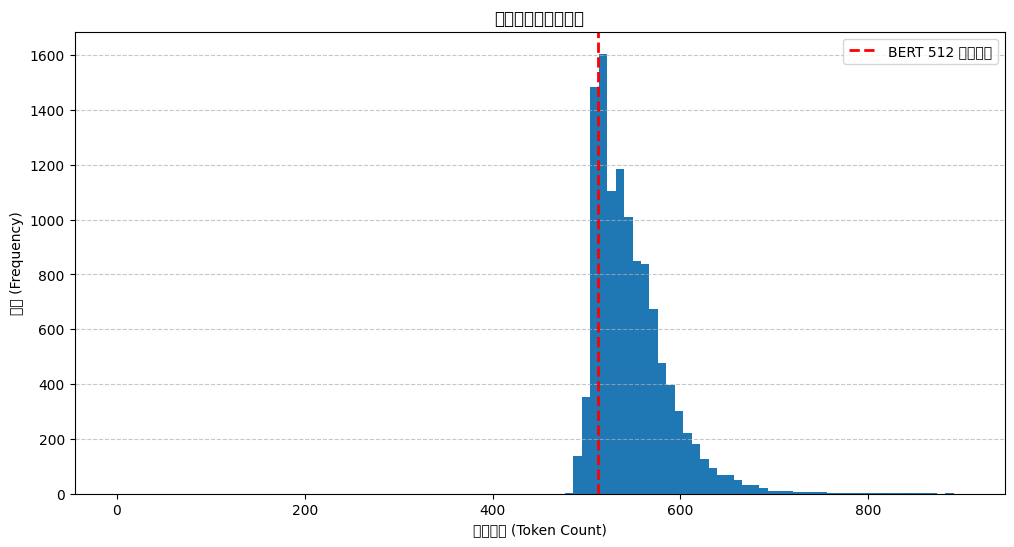

In [ ]:
# --- 步骤 6.5：验证词元长度 ---

# 确保您已经运行了步骤5（创建了 full_text_list）
# 和步骤6（加载了 tokenizer）

if 'full_text_list' in locals() and 'tokenizer' in locals():
    print("正在开始词元长度分析... (这可能需要一两分钟)")

    # 1. 对所有文本进行分词（关闭padding和truncation以获取真实长度）
    #    tokenizer() 会返回一个包含 'input_ids' 列表的对象
    tokenized_output = tokenizer(
        full_text_list, 
        padding=False,        # !!! 关闭填充
        truncation=False,     # !!! 关闭截断
    )
    
    # 2. 计算每个字符串的词元长度
    token_lengths = [len(ids) for ids in tokenized_output['input_ids']]
    
    # 3. 分析和报告结果
    if token_lengths:
        token_lengths_np = np.array(token_lengths)
        
        print("\n--- 词元长度分析报告 ---")
        print(f"总行数: {len(token_lengths_np)}")
        print(f"最大词元长度 (Max Tokens): {np.max(token_lengths_np)}")
        print(f"最小词元长度 (Min Tokens): {np.min(token_lengths_np)}")
        print(f"平均词元长度 (Avg Tokens): {np.mean(token_lengths_np):.2f}")
        print(f"中位数词元长度 (Median Tokens): {np.median(token_lengths_np)}")
        
        # --- 关键：检查有多少行超出了限制 ---
        over_limit_count = np.sum(token_lengths_np > 512)
        over_limit_percent = (over_limit_count / len(token_lengths_np)) * 100
        
        print(f"\n--- 512 词元限制分析 ---")
        print(f"!!! 超出 512 词元限制的行数: {over_limit_count} !!!")
        print(f"!!! 超出限制的行所占百分比: {over_limit_percent:.2f}% !!!")

        # 4. (可选) 绘制直方图以查看分布
        try:
            import matplotlib.pyplot as plt
            
            plt.figure(figsize=(12, 6))
            plt.hist(token_lengths_np, bins=100, range=(0, np.max(token_lengths_np) + 10))
            # 绘制 512 词元的红线
            plt.axvline(x=512, color='red', linestyle='--', linewidth=2, label='BERT 512-token Limit')
            plt.title('Token Length Distribution Histogram')
            plt.xlabel('Token Count')
            plt.ylabel('Frequency')
            plt.legend()
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.show()
            
        except ImportError:
            print("\n(未安装 'matplotlib'。跳过直方图绘制。)")
            print("(您可以运行 'pip install matplotlib' 来启用此图表。)")

    else:
        print("未找到词元长度信息。")
else:
    print("错误：请先确保您已成功运行步骤 5 和 步骤 6。")

## 步骤 7：生成特征嵌入（分批处理）

In [16]:
BATCH_SIZE = 32  # 您可以根据您 GPU 显存大小调整此值
all_embeddings = []

# 使用 tqdm 显示批处理进度
for i in tqdm(range(0, len(full_text_list), BATCH_SIZE), desc="[2/3] 生成特征嵌入"):
    
    # 1. 获取当前批次的文本
    batch_texts = full_text_list[i : i + BATCH_SIZE]
    
    # 2. 批量分词 (Tokenize)
    inputs = tokenizer(
        batch_texts, 
        padding=True,        # 填充到批次中的最大长度
        truncation=True,     # 截断超过512个token的文本
        max_length=512,      # BERT 的最大长度
        return_tensors='pt'  # 返回 PyTorch 张量
    )
    
    # 3. 将输入数据发送到 GPU
    inputs = {key: val.to(DEVICE) for key, val in inputs.items()}
    
    # 4. 模型推理 (Inference)
    with torch.no_grad():  # 在推理时关闭梯度计算
        outputs = model(**inputs)
        
    # 5. 提取 [CLS] 向量 (pooler_output) 并移回 CPU
    batch_embeddings = outputs.pooler_output.cpu().numpy()
    
    # 6. 收集结果
    all_embeddings.append(batch_embeddings)

# 7. 将所有批次的向量堆叠成一个大的 NumPy 矩阵
X_nlp = np.vstack(all_embeddings)

print("\n特征嵌入生成完毕。")
print(f"最终特征矩阵 (X_nlp) 形状: {X_nlp.shape}")

[2/3] 生成特征嵌入:   1%|          | 3/356 [00:26<52:53,  8.99s/it]


KeyboardInterrupt: 

## 步骤 8：保存处理后的特征
将这个高维的NumPy矩阵 X_nlp 保存到 data/processed 文件夹中。使用 pickle 来保存，因为它可以高效地序列化NumPy数组。

In [9]:
# 确保 'data/processed' 目录存在
os.makedirs(PROCESSED_DIR, exist_ok=True)

# 使用 pickle 保存 NumPy 矩阵
try:
    with open(OUTPUT_FILE, 'wb') as f:
        pickle.dump(X_nlp, f)
    print(f"\n[3/3] 成功！处理后的特征已保存到: {OUTPUT_FILE}")
except IOError as e:
    print(f"错误: 保存文件失败. {e}")


[3/3] 成功！处理后的特征已保存到: ..\data\processed\california_nlp_features.pkl
